In [17]:
# Section 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

# Locate the output folder
output_folder = Path("lww_output")

# Load CSV files
density_file = output_folder / "lww_pydensity.csv"
potential_file = output_folder / "lww_pypoten.csv"
wigner_file = output_folder / "lww_pywigner.csv"
wigner_ss_file = output_folder / "lww_pywigner_ss.csv"

# Load density and potential as 1D arrays
density = pd.read_csv(density_file, header=None).values.flatten()
potential = pd.read_csv(potential_file, header=None).values.flatten()

# Load Wigner functions as 2D arrays
# The files contain flattened data, so we need to determine grid size from the density/potential
Nx = len(density)
wigner = pd.read_csv(wigner_file, header=None).values.flatten()
wigner_ss = pd.read_csv(wigner_ss_file, header=None).values.flatten()

# Infer momentum grid size (assuming square or rectangular grid)
N = len(wigner) // Nx if Nx > 0 else 1
wigner = wigner.reshape(Nx, N)
wigner_ss = wigner_ss.reshape(Nx, N)

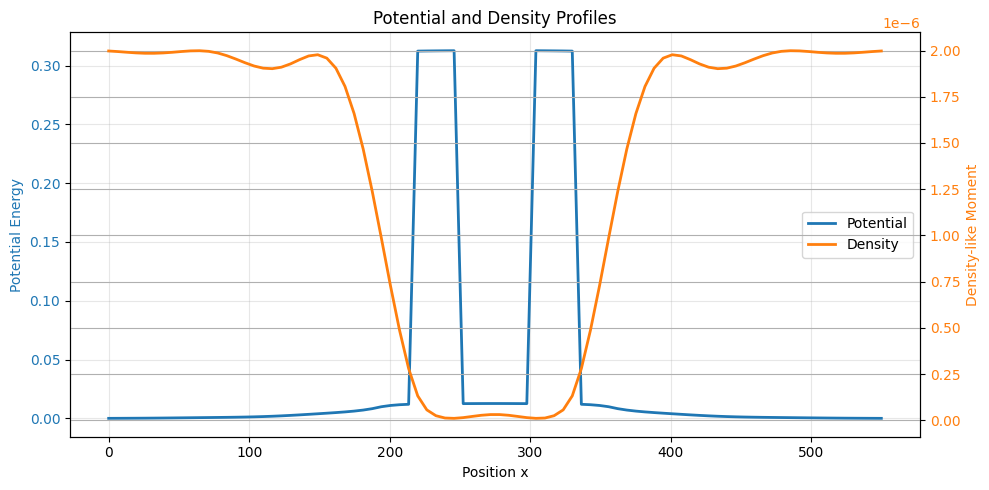

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
output_folder = Path("lww_output")

density_file = output_folder / "lww_pydensity.csv"
potential_file = output_folder / "lww_pypoten.csv"

density = np.loadtxt(density_file, delimiter=",")
potential = np.loadtxt(potential_file, delimiter=",")

Nx = len(potential)
box = 550.0
x = np.linspace(0.0, box, Nx)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(x, potential, color="tab:blue", linewidth=2, label="Potential")
ax1.set_xlabel("Position x")
ax1.set_ylabel("Potential Energy", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(x, density, color="tab:orange", linewidth=2, label="Density")
ax2.set_ylabel("Density-like Moment", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Potential and Density Profiles")
fig.tight_layout()
plt.show()


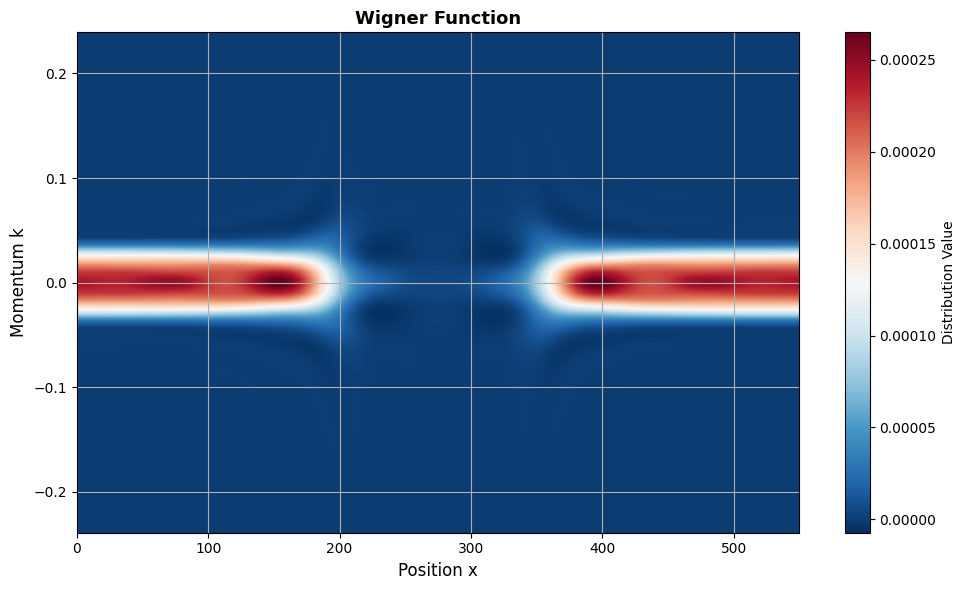

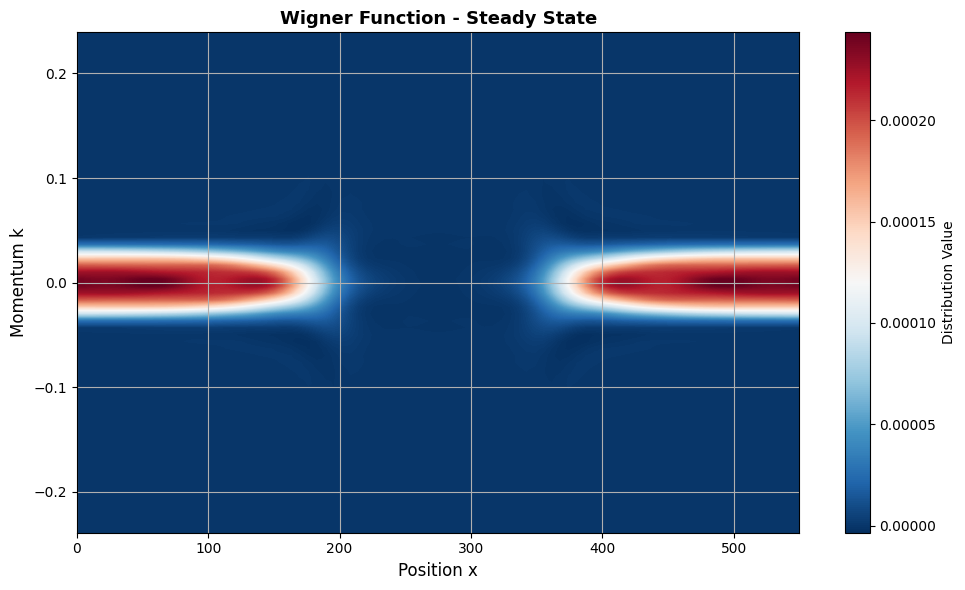

In [19]:
# Plot Wigner function
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    wigner.T,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), k.min(), k.max()],
    cmap='RdBu_r',
    interpolation='bilinear'
)

ax.set_xlabel('Position x', fontsize=12)
ax.set_ylabel('Momentum k', fontsize=12)
ax.set_title('Wigner Function', fontsize=13, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Distribution Value')
plt.tight_layout()
plt.show()

# Plot steady-state Wigner function
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(
    wigner_ss.T,
    origin='lower',
    aspect='auto',
    extent=[x.min(), x.max(), k.min(), k.max()],
    cmap='RdBu_r',
    interpolation='bilinear'
)

ax.set_xlabel('Position x', fontsize=12)
ax.set_ylabel('Momentum k', fontsize=12)
ax.set_title('Wigner Function - Steady State', fontsize=13, fontweight='bold')
cbar = plt.colorbar(im, ax=ax, label='Distribution Value')
plt.tight_layout()
plt.show()

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

source = Path("lww_output/lww_pywigner.csv")
values = np.loadtxt(source, delimiter=",").reshape(86, 72)

x = np.linspace(-0.025, 0.025, values.shape[0])
k = np.linspace(-0.025, 0.025, values.shape[1])
X, K = np.meshgrid(x, k, indexing="ij")
Z = values * 1.0e3

fig = plt.figure(figsize=(8.26, 6.24), constrained_layout=True)
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X,
    K,
    Z,
    cmap="viridis",
    edgecolor="none",
    linewidth=0,
    antialiased=True,
    alpha=0.95,
)

ax.set_xlabel("Position (1e06)", labelpad=8)
ax.set_ylabel("Momentum (1e-09)", labelpad=8)
ax.set_zlabel("Wigner Function (1e03)", labelpad=8)

ax.set_xlim(-0.028, 0.028)
ax.set_ylim(-0.028, 0.028)
ax.set_zlim(0.0, 0.25)

ax.view_init(elev=24, azim=-62)

try:
    ax.set_box_aspect((1.35, 1.0, 0.72))
except AttributeError:
    pass

fig.savefig("wigner_function.png", dpi=100, bbox_inches="tight")
# plt.show()
